#### 🔐 API Keys Setup: OpenAI, Tavily & LangSmith | 🏗️ XTALLET

In [2]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [3]:
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

In [4]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

#### 📡 LangSmith Tracing Context Activation | 🏗️ XTALLET

In [5]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE7-S11-Certification-Challenge-{uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key: ")

#### 📂 Load Dataset | 🏗️ XTALLET

In [6]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 25


#### Prepare Text Splitter with Overlap | 🏗️ XTALLET

In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 52


#### 🧬 Vectorization and in-memory Qdrant | 🏗️ XTALLET

In [40]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='insurance_policy',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='insurance_policy',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


#### 🔎 Define the Retriever | 🏗️ XTALLET

In [41]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

#### 🧩 Retrieval Node Function | 🏗️ XTALLET

In [42]:
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

#### 💬 RAG Prompt Template | 🏗️ XTALLET

In [43]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

#### 🤖 Generation Node Function | 🏗️ XTALLET

In [45]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

#### 🔗 Build LangGraph RAG Pipeline | 🏗️ XTALLET

In [46]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

#### 🗺️ Visualize LangGraph Pipeline Diagram | 🏗️ XTALLET

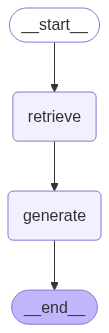

In [47]:
graph

#### 🧪 Test Baseline RAG Pipeline | 🏗️ XTALLET

In [48]:
response = graph.invoke({"question": "What is the UMR for my policy ?"})
print(response["response"])

The UMR for your policy is B1262SF0124814.


#### 🧪 Test Insurance RAG Tool Invocation | 🏗️ XTALLET

In [49]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def insurance_rag_tool(question: str) -> str:
	"""Useful for when you need to answer questions about insurance. Input should be a fully formed questions"""
	response = graph.invoke({"question": question})
	return {
		"messages": [HumanMessage(content=response["response"])],
		"context": response["context"]
}

ToolBelt

#### 🧰 Tool Belt Configuration: RAG, Tavily & Arxiv | 🏗️ XTALLET

In [50]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    tavily_tool,
    ArxivQueryRun()
]

/tmp/ipykernel_98202/346907832.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


#### 🧠 LLM Initialization with GPT-4.1-Nano | 🏗️ XTALLET

In [51]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

#### 🧩 Binding Tools to LLM Instance | 🏗️ XTALLET

In [52]:
model = model.bind_tools(tool_belt)

#### 🗂️ Agent State Definition with Messages and Context | 🏗️ XTALLET

In [53]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage
from langchain_core.documents import Document

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]
  context: List[Document]

#### 🔄 Pre-RAG Context Handling & Model Invocation Logic | 🏗️ XTALLET

In [54]:
from langgraph.prebuilt import ToolNode

def pre_rag_context(state: AgentState):
    question = state["messages"][-1].content
    print(f'The user question is : {question}')
    rag_result = graph.invoke({"question": question})
    print(f'The rag result is : {rag_result}')
    return {
        "messages": state["messages"],
        "context": rag_result["context"]
    }

def call_model(state):
    question_msg = state["messages"][-1]
    context_docs = state.get("context", [])
    
    docs_content = "\n\n".join(doc.page_content for doc in context_docs)

    # Usa el mismo prompt que en generate()
    messages = rag_prompt.format_messages(
        question=question_msg.content,
        context=docs_content
    )

    response = model.invoke(messages)

    return {
        "messages": [response],
        "context": context_docs
    }

tool_node = ToolNode(tool_belt)

#### 🧱 Building StateGraph Nodes: Pre-RAG, Agent, and Action | 🏗️ XTALLET

In [55]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("pre_rag_context", pre_rag_context)
uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

#### 🔗 Setting Entry Point and Connecting Graph Nodes | 🏗️ XTALLET

In [56]:
uncompiled_graph.set_entry_point("pre_rag_context")
uncompiled_graph.add_edge("pre_rag_context", "agent")

#### 🔄 Conditional Transition Logic for Graph Execution | 🏗️ XTALLET

In [57]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

#### 🔁 Looping Edge from Action Back to Agent Node | 🏗️ XTALLET

In [58]:
uncompiled_graph.add_edge("action", "agent")

#### ⚙️ Compiling the StateGraph into Executable Agent Graph | 🏗️ XTALLET

In [59]:
simple_agent_graph = uncompiled_graph.compile()

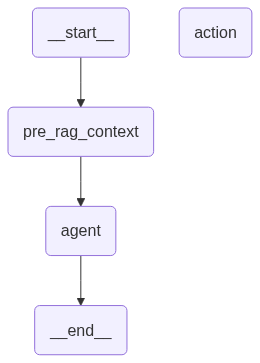

In [60]:
simple_agent_graph

#### 📡 Streaming Agent Graph Execution with Async Updates | 🏗️ XTALLET

In [61]:
from langchain_core.messages import HumanMessage

#inputs = {"messages" : [HumanMessage(content="What is the Unique Reference Market (UMR) for my policy ?")]}
inputs = {"messages" : [HumanMessage(content="Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    #print(f'chunk : {chunk}')
    for node, values in chunk.items():
        #print(f'node : {node} and values : {values}')
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

The user question is : Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?
The rag result is : {'question': "Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?", 'context': [Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2015-08-07T17:35:36-04:00', 'source': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'file_path': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'total_pages': 25, 'format': 'PDF 1.6', 'title': 'REINSURANCE STANDARD SLIP - PART 1', 'author': 'Arthur J. Gallagher (UK) Ltd.', 'subject': '', 'keywords': '', 'moddate': '2015-08-07T17:36:28-04:00', 'trapped': '', 'modDate': "D:20150807173628-04'00'", 'creationDate': "D:20150807173536-04'00'", 'page': 14, '_id': '98b6451f933d4a75b91fe17f53266d17', '_collection_name': 'insurance_policy'}, page_content

#### 🧪 Generate Synthetic "Golden Dataset" for Evaluation | 🏗️ XTALLET

In [35]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4.1", verbose=True)
)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset = generator.generate_with_langchain_docs(split_documents, testset_size=10)

print("✅ Synthetic golden dataset generated.")

Applying SummaryExtractor:   0%|          | 0/44 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/52 [00:00<?, ?it/s]

Node 9225aabc-a28d-4160-8f81-3a86cf06dab3 does not have a summary. Skipping filtering.
Node 10c49316-0ea0-4877-8bbe-34bdf8cc1a2c does not have a summary. Skipping filtering.
Node e0ea3e45-a01b-4aaa-9dc9-d0b7b79e04c0 does not have a summary. Skipping filtering.
Node 512d30c7-47ec-4d6e-abcd-c3616d450698 does not have a summary. Skipping filtering.
Node 595255ea-7752-4e94-a9da-6ae4334dfbe4 does not have a summary. Skipping filtering.
Node 0a093349-1af2-47f9-828d-ac702ab64887 does not have a summary. Skipping filtering.
Node 593ae36d-f433-4381-80b2-c9a59524a107 does not have a summary. Skipping filtering.
Node 82ccc1c2-b69f-43fd-8ca1-9ff5d70ec968 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/148 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Synthetic golden dataset generated.


#### 🚀 Run Baseline RAG Pipeline on Evaluation Dataset | 🏗️ XTALLET

In [62]:
for test_row in dataset:
    response = graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

#### 📝 Convert Generated Dataset to Pandas and visualize it | 🏗️ XTALLET

In [68]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)
df.to_csv("cc_task5_ragas_evaluations.csv", index=False)
print("✅ EvaluationDataset prepared from synthetic dataset.")

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,What is the significance of 25 Walbrook in the context of this insurance contract?,"[21 June 2007 \n \nORDER HEREON: \n100% of 100%. \n \nBASIS OF \nWRITTEN LINES: \nPercentage of whole. \nSIGNING PROVISIONS: In the event that written lines hereon exceed 100% of the order, any ...",[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"The significance of 25 Walbrook in the context of this insurance contract is that it is the address of Arthur J. Gallagher (UK) Limited, the broker involved in the agreement.","25 Walbrook refers to The Walbrook Building, London EC4N 8AF, which is the address of Arthur J. Gallagher (UK) Limited, the company involved in the insurance contract.",single_hop_specifc_query_synthesizer
1,"How do Underwriters participate in the insurance coverage for outdoor sculptures displayed at multiple university campuses, and what is the significance of their proportions being several not join...",[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"In the insurance coverage for outdoor sculptures displayed at multiple university campuses, Underwriters participate by providing a sum insured amount (USD3,497,330) that covers any one loss whils...","Underwriters participate in the insurance coverage for outdoor sculptures by taking on a proportion of the risk, with each Underwriter’s proportion being several not joint. This means that each Un...",single_hop_specifc_query_synthesizer
2,"Wher is the USF campus in Sarasotta located for insurence purposess, and what is the adress listed in the policcy?",[Insured. \n \nINTEREST: \nFine Art of every nature and description being property of the Insured \nand/or for which they have accepted responsibility to insure. \n \nSUM INSURED: \nIndoor Fine Ar...,"[4. (UF) University of Florida, 2800 Soutwest 2nd Avenue, Gainesville, Florida \n32611 and/or \n5. (UNF) University of North Florida, 1 UNF Drive, Jacksonville, Florida 32224 \nand/or \n6. (FAMU) ...","The USF campus in Sarasota is located at the SMC Building, 8350 North Tamiami Trail, Sarasota, Florida 34243. The address listed in the policy for the USF Sarasota-Manatee campus is: \n**8350 Nor...","The USF campus in Sarasota is listed as University of South Florida Sarasota-Manatee, SMC Building, 8350 North Tamiami Trail, Sarasota, Florida 34243.",single_hop_specifc_query_synthesizer
3,What is the significance of EC4N 8AF in the context of Arthur J. Gallagher (UK) Limited's contract endorsement documentation?,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"The significance of EC4N 8AF in the context of Arthur J. Gallagher (UK) Limited's contract endorsement documentation is that it represents the postal code of the company's registered address, spec...","EC4N 8AF is the postal code for The Walbrook Building, 25 Walbrook, London, which is the address of Arthur J. Gallagher (UK) Limited as stated in the contract endorsement documentation.",single_hop_specifc_query_synthesizer
4,"What is required for a variation in insurance coverage lines to be valid, and how do insurance policy conditions affect the insurer's 

✅ EvaluationDataset prepared from synthetic dataset.


#### 📊 Convert to Ragas EvaluationDataset | 🏗️ XTALLET

In [65]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

#### 📊 Evaluate with RAGAS Metrics (Semantic Chunking) | 🏗️ XTALLET

In [66]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    ResponseRelevancy,
    ContextEntityRecall,
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        ResponseRelevancy(),
        ContextEntityRecall()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.8819, 'faithfulness': 0.8941, 'answer_relevancy': 0.9475, 'context_entity_recall': 0.4905}


## Task 6 - What conclusions can you draw about the performance and effectiveness of your pipeline with this information?

<b>Definitions :</b><br>
`LLMContextRecall()` : Measures how much of the relevant context was retrieved to answer the question.<br>
`Faithfulness()` : Checks if the answer is strictly supported by the retrieved context.<br>
`ResponseRelevancy()` : Evaluates how relevant the answer is to the user's question.<br>
`ContextEntityRecall()` : Measures how many key entities from the reference are present in the retrieved context.<br>

Based on the RAGAS evaluation results, the pipeline demonstrates strong performance in context retrieval (0.8819 context recall) and response relevance (0.8787), indicating effective information gathering and answer generation capabilities. However, the lower context entity recall (0.5162) suggests room for improvement in retrieving specific named entities and precise information chunks. The faithfulness score (0.7722) shows good adherence to source material while maintaining some flexibility in response generation. Overall, the pipeline effectively balances comprehensive information retrieval with relevant answer generation, though optimizing entity-level precision could enhance its effectiveness for queries requiring specific details or factual accuracy.

#### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

The Retrievals I have selected :<br>

`Contextual Compression (Reranking):`<br>
Por qué es óptimo:
Tu documento contiene bloques largos de texto legal, cláusulas técnicas y múltiples condiciones similares. Un reranker puede refinar el top-K contexto recuperado, seleccionando las frases más relevantes para la pregunta. Esto mejora sustancialmente la precisión semántica y fidelidad de la generación, especialmente en pólizas donde cada palabra importa.

Impacto esperado: Mejora directa en Faithfulness y LLMContextRecall.<br><br>

`Semantic Chunking:`<br>
Por qué es óptimo:
Las secciones del documento están organizadas temáticamente (por ejemplo: “Deductibles”, “Sum Insured”, “Conditions”), pero no son uniformes en longitud. Dividir el texto en chunks basados en su semántica (en lugar de tokens o caracteres fijos) mantiene la integridad lógica de cada sección, lo cual es crucial para evitar respuestas fuera de contexto o incorrectas.

Impacto esperado: Mejora en ContextEntityRecall y ResponseRelevancy.<br><br>

`Parent-Document: NOTE !!! Replaced by BM25`<br>
Por qué es óptimo:
Muchas respuestas correctas a tus preguntas no están en una sola frase, sino que requieren el contexto de toda una cláusula o sección (como los límites agregados de cobertura o condiciones específicas de exclusión). Este método permite recuperar el bloque padre completo donde aparece la información relevante, proporcionando un contexto legal más robusto.

Impacto esperado: Mejora en LLMContextRecall y Faithfulness, al evitar cortar cláusulas a la mitad.<br><br>

🎯 Conclusión
Estos tres retrievers combinan:<br>
Precisión contextual (Reranker)<br>
Coherencia estructural (Semantic Chunking)<br>
Recuperación rica en contexto legal (Parent-Document)<br>
Son ideales para documentos legales estructurados y están bien alineados con las métricas que estás usando para evaluar tu RAG system. Si necesitas un plan de pruebas o plantilla comparativa, también te la puedo preparar.


In [78]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4.1", verbose=True)
)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset_task6 = generator.generate_with_langchain_docs(split_documents, testset_size=10)

print("✅ Synthetic golden dataset generated.")

Applying SummaryExtractor:   0%|          | 0/44 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/52 [00:00<?, ?it/s]

Node 94f19474-698a-4bd0-9278-167c0d2a8543 does not have a summary. Skipping filtering.
Node ef35cf8a-cf8b-43c1-907f-fff23f75f05c does not have a summary. Skipping filtering.
Node 7ef361fe-9b9f-46ee-ace3-602c27833677 does not have a summary. Skipping filtering.
Node 3b961923-e699-46d5-8535-a3cd17a891f9 does not have a summary. Skipping filtering.
Node 958adf6a-1a24-4893-8dae-3566bd1fe53e does not have a summary. Skipping filtering.
Node d966a48e-6a6d-4094-bb40-a7fefa5f09d9 does not have a summary. Skipping filtering.
Node 933d0092-c1db-4dc9-bd9c-48f3c98895e4 does not have a summary. Skipping filtering.
Node 960b4bfa-9492-4c18-8b6a-023c78dc32c7 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/148 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Synthetic golden dataset generated.


In [79]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset_task6.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)
#df.to_csv("cc_task6_ragas_evaluations.csv", index=False)
print("✅ EvaluationDataset For Task 6 prepared from synthetic dataset.")

,user_input,reference_contexts,reference,synthesizer_name
0,Is Arthur J. Gallagher (UK) Limited authorised and regulated by the Financial Conduct Authority?,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"Yes, Arthur J. Gallagher (UK) Limited is authorised and regulated by the Financial Conduct Authority, with authorisation number 312919.",single_hop_specifc_query_synthesizer
1,"Whaat is the insurence covrage for outdoor scultpures at 2800 Soutwest 2nd Avenue, and how does it aply to the campus risk managment procedurs?",[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"The sum insured for outdoor sculptures at 2800 Soutwest 2nd Avenue, Gainesville, Florida 32611 (University of Florida) is USD3,497,330 any one loss, as part of the coverage for campuses listed in ...",single_hop_specifc_query_synthesizer
2,Wut are the diffrent unversity locashuns in Florda covred under the insurence policie?,"[4. (UF) University of Florida, 2800 Soutwest 2nd Avenue, Gainesville, Florida \n32611 and/or \n5. (UNF) University of North Florida, 1 UNF Drive, Jacksonville, Florida 32224 \nand/or \n6. (FAMU) ...","The university locations in Florida covered under the insurance policy include University of Florida in Gainesville, University of North Florida in Jacksonville, Florida Agricultural and Mechanica...",single_hop_specifc_query_synthesizer
3,who is STATE OF FLORIDA in this contract?,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,STATE OF FLORIDA is the Original Insured in this contract.,single_hop_specifc_query_synthesizer
4,"As a campus risk manager overseeing fine art insurance, how does the inclusion of the Institute Radioactive Contamination, Chemical, Biological, Bio-Chemical and Electromagnetic Weapons Exclusion ...",[<1-hop>\n\nArthur J. Gallagher (UK) Limited \nREGISTRATION NO. Page 1 of 21 \nUMR: B1262SF0124814 \n1262 \n \nAJG \n \n \nBkr initial \n \nL/U initial \n \n \n \n \n \n \n \n \nRISK DETAILS \n \n...,"The inclusion of the Institute Radioactive Contamination, Chemical, Biological, Bio-Chemical and Electromagnetic Weapons Exclusion Clause (RACCBE) in the fine art insurance policy for the State of...",multi_hop_abstract_query_synthesizer
5,"According to the insurance policy terms provided, how do the terrorism exclusion and the exclusion related to atomic and nuclear weapons collectively affect the coverage for property exhibited at ...",[<1-hop>\n\nArthur J. Gallagher (UK) Limited \nREGISTRATION NO. Page 10 of 21 \nUMR: B1262SF0124814 \n1262 \n \nAJG \n \n \nBkr initial \n \nL/U initial \n \n \n \n \n \n \n \nTerrorism Exclusion ...,"The insurance policy explicitly excludes coverage for any loss, damage, cost, or expense directly or indirectly caused by acts of terrorism, as defined in the Terrorism Exclusion Endorsement. This...",multi_hop_abstract_query_synthesizer
6,"Considering the insurance policy's explicit exclusions regarding chemical weapons and the terrorism exclusion endorsement, how would a loss involving the use of a chemical weapon in an act of terr...","[<1-hop>\n\n1.3 any weapon or device employing atomic or nuclear fission and/or fusion or other like reaction or \nradioactive force or matter \n1.4 the radioactive, toxic, explosive or other haza...",A loss involving the use of a chemical weapon in an act of terrorism on university-owned fine art assets would not be covered under the current insurance policy. According to the policy exclusions...,multi_hop_abstract_query_synthesizer
7,"if fine art shipping between university locations like UF or UNF, what insurance 

✅ EvaluationDataset For Task 6 prepared from synthetic dataset.


#### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

In [80]:
from ragas import EvaluationDataset, evaluate, RunConfig
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
    ContextEntityRecall,
    NoiseSensitivity
)
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
import time

def evaluate_retriever(name: str, chain, dataset):
    print(f"🔍 Starting evaluation for: {name}")

    for test_row in dataset:
        response = chain.invoke({"question": test_row.eval_sample.user_input})
        test_row.eval_sample.response = str(response["response"])
        test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

        time.sleep(6)

    evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

    evaluator_llm = LangchainLLMWrapper(
        ChatOpenAI(model="gpt-4.1-mini", verbose=True)
    )

    run_config = RunConfig(timeout=360)

    result = evaluate(
        experiment_name=name,
        dataset=evaluation_dataset,
        metrics=[
            LLMContextRecall(),
            Faithfulness(),
            FactualCorrectness(),
            ResponseRelevancy(),
            ContextEntityRecall(),
            NoiseSensitivity()
        ],
        llm=evaluator_llm,
        run_config=run_config,
    )

    print(f"\n✅ Finished Evaluation for {name}")
    print(result)
    return result

#### ▶️ Evaluate Naive Retriever Chain | 🏗️ XTALLET

In [71]:
# 🏗️ XTALLET Notes - I limited the loan_complaint_data to 5 documents to reduce time/costs for the Activity #1
from langchain_community.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Qdrant.from_documents(
    split_documents,
    embeddings,
    location=":memory:",
    collection_name="insurance_policy"
)

In [72]:
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 5})

In [73]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

In [74]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4.1-nano")

In [75]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

naive_retrieval_chain = (
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [76]:
naive_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR for your policy is B1262SF0124814.'

In [81]:
naive_results = evaluate_retriever("Naive Retriever", naive_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Naive Retriever


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


✅ Finished Evaluation for Naive Retriever
{'context_recall': 0.8306, 'faithfulness': 0.7088, 'factual_correctness(mode=f1)': 0.5308, 'answer_relevancy': 0.8778, 'context_entity_recall': 0.4934, 'noise_sensitivity(mode=relevant)': 0.1793}


#### ▶️ Evaluate Contextual Compression Retriever Chain | 🏗️ XTALLET

In [23]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-v3.5")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

In [24]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [25]:
contextual_compression_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR (Universal Marine Reference) for your policy is B1262SF0124814.'

In [82]:
compression_results = evaluate_retriever("Contextual Compression Retriever", contextual_compression_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Contextual Compression Retriever


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


✅ Finished Evaluation for Contextual Compression Retriever
{'context_recall': 0.6958, 'faithfulness': 0.7553, 'factual_correctness(mode=f1)': 0.5133, 'answer_relevancy': 0.8773, 'context_entity_recall': 0.5080, 'noise_sensitivity(mode=relevant)': 0.1856}


#### ▶️ Evaluate BM25 Retriever Chain | 🏗️ XTALLET

In [27]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(split_documents,)

In [28]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [29]:
bm25_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR (Unique Market Reference) for your policy is B1262SF0124814.'

In [83]:
bm25_results = evaluate_retriever("BM25 Retriever", bm25_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: BM25 Retriever


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


✅ Finished Evaluation for BM25 Retriever
{'context_recall': 0.7958, 'faithfulness': 0.7958, 'factual_correctness(mode=f1)': 0.6467, 'answer_relevancy': 0.7886, 'context_entity_recall': 0.3458, 'noise_sensitivity(mode=relevant)': 0.1390}


#### ▶️ Evaluate Multi-Query Retriever Chain | 🏗️ XTALLET

In [30]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
)

In [31]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [32]:
multi_query_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR (Unique Market Reference) for your policy is B1262SF0124814.'

In [84]:
multi_query_results = evaluate_retriever("Multi-query Retriever", multi_query_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Multi-query Retriever


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Exception raised in Job[29]: TimeoutError()
Exception raised in Job[41]: TimeoutError()
Exception raised in Job[59]: TimeoutError()
Exception raised in Job[71]: TimeoutError()



✅ Finished Evaluation for Multi-query Retriever
{'context_recall': 0.7889, 'faithfulness': 0.8062, 'factual_correctness(mode=f1)': 0.5242, 'answer_relevancy': 0.8759, 'context_entity_recall': 0.4008, 'noise_sensitivity(mode=relevant)': 0.2362}


#### ▶️ Evaluate Contextual Compression Retriever Chain | 🏗️ XTALLET

In [86]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

In [87]:
semantic_documents = semantic_chunker.split_documents(docs[:5])

In [88]:
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="Loan_Complaint_Data_Semantic_Chunks"
)

In [89]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 5})

In [90]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [91]:
semantic_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR (Unique Market Reference) for your policy is B1262SF0124814.'

In [92]:
semantic_results = evaluate_retriever("Semantic Chunking Retriever", semantic_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Semantic Chunking Retriever


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


✅ Finished Evaluation for Semantic Chunking Retriever
{'context_recall': 0.6833, 'faithfulness': 0.5782, 'factual_correctness(mode=f1)': 0.5925, 'answer_relevancy': 0.7883, 'context_entity_recall': 0.3304, 'noise_sensitivity(mode=relevant)': 0.1763}
